# Final Project

**Authors:** Luka Gikic and Celian Fabas

**Slides link:** https://docs.google.com/presentation/d/14eoOXBEMeleftacQh7sLLx_9MwYYB0IvoaHnFf4ZNfc/edit?usp=sharing


# 0. Task Breakdown

Problem statement:
How to give an intrinsic price to a European option (Call) using the Black-Scholes model, with volatility informed by the SABR stochastic model.

Resolution steps:
1. Build the base functions for both models.
2. Create a CSV file containing options data to use with the code, or import the data directly with yfinance.
3. Calibrate the SABR model parameters using real volatility data for the given ticker.
4. Derive the implied volatility surface from it.
5. Overlay the current price with the implied volatility.
6. Annotate and comment the functions, make the code readable.
7. Make the slides.


## 1. Introduction

Modern financial markets rely on the ability to value complex derivative products such as options. A call option gives its holder the right, but not the obligation, to buy an underlying asset at a fixed price (the strike) at a future date.

Historically, the **Black-Scholes model (1973)** revolutionized finance by providing a closed-form formula for the price of these options. However, this model rests on a strong assumption: the volatility of the asset is constant. Yet market observations (especially since the 1987 crash) show that implied volatility varies with strike and maturity, forming what is called the "smile" or the volatility surface.

**Problem statement:** How can we obtain a more realistic price for a European call option while keeping the Black-Scholes pricing framework, but injecting into it a dynamic volatility modeled by the stochastic **SABR** model?

This project aims to implement this hybrid approach: use SABR to calibrate and predict the correct volatility surface, then use that volatility in the Black-Scholes formula for pricing.


## 2. The two models

### 2.1 The Black-Scholes model
The Black-Scholes-Merton model assumes that the price of the underlying asset $S_t$ follows a geometric Brownian motion:
$$ dS_t = \mu S_t dt + \sigma S_t dW_t $$
where $\sigma$ is assumed to be constant volatility.
The Black-Scholes formula for a Call is given by:
$$ C(S, K, T) = S N(d_1) - K e^{-rT} N(d_2) $$
Although theoretically elegant, this model fails to capture volatility risk (the fact that volatility itself changes). In markets, traders quote options in terms of "implied volatility", i.e. the parameter $\sigma$ that would need to be plugged into the formula to recover the market price. We observe that this $\sigma$ is not flat.

### 2.2 The SABR model (Stochastic Alpha, Beta, Rho)
To address the shortcomings of Black-Scholes, Hagan et al. (2002) introduced the SABR model. It is a stochastic volatility model where volatility itself follows a random process:
$$ dF_t = \alpha_t F_t^\beta dW_{1t} $$
$$ d\alpha_t = \nu \alpha_t dW_{2t} $$
with a correlation $\rho$ between the two Brownian motions.

The parameters are:
*   $\alpha$: the initial volatility level.
*   $\beta$: the exponent (elasticity of variance), determining the relationship between price and volatility (0 for normal, 1 for log-normal).
*   $\rho$: the correlation between the asset price and its volatility (governs the "skew"/asymmetry).
*   $\nu$: the "volatility of volatility" (vol-of-vol), which governs the curvature of the smile.

#### Hagan's asymptotic approximation
One of the main advantages of the SABR model is that it provides a closed-form approximation for the Black-Scholes implied volatility $\sigma_{imp}(K, F)$. This asymptotic formula (Hagan et al., 2002) is used to calibrate the model to market prices:

$$ \sigma_{SABR}(K, F) \approx \frac{\alpha}{(FK)^{(1-\beta)/2} \left[ 1 + \frac{(1-\beta)^2}{24} (\ln(F/K))^2 + \frac{(1-\beta)^4}{1920} (\ln(F/K))^4 \right]} \cdot \left(\frac{z}{x(z)}\right) \cdot \left[ 1 + \left( \frac{(1-\beta)^2}{24} \frac{\alpha^2}{(FK)^{1-\beta}} + \frac{1}{4} \frac{\rho \beta \nu \alpha}{(FK)^{(1-\beta)/2}} + \frac{2-3\rho^2}{24} \nu^2 \right) T \right] $$

Where:
$$ z = \frac{\nu}{\alpha} (FK)^{(1-\beta)/2} \ln(F/K) $$
$$ x(z) = \ln \left( \frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho} \right) $$

### 2.3 Why SABR is needed alongside Black-Scholes
The SABR model is particularly valued because it provides a very accurate analytical approximation of Black-Scholes implied volatility $\sigma_{imp}(K, F)$.
Instead of using a constant $\sigma$, we use SABR to compute $\sigma_{SABR}(K)$ for each strike. This "SABR" volatility is then injected into the Black-Scholes formula. This keeps the simplicity of the Black-Scholes formula (used as a market standard, or "quotation device") while incorporating the complex, realistic market dynamics captured by SABR.


## 3. Algorithm and analysis

### 3.1 Importing modules


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime

### 3.2 Defining the Black-Scholes call function


In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Computes the price of a call under the Black-Scholes model

    S : float : current price of the underlying asset
    K : float : strike price
    T : float : time to maturity (in years)
    r : float : continuously compounded annual risk-free rate
    sigma : float : volatility
    
    Returns the call price for the given parameters.
    """
    if T <= 0 or sigma <= 1e-6: # Near-zero volatility
        return max(S - K, 0)

    # If K=0 we risk log(0)
    if K <= 0:
        return S

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma) : 
    """
    Computes the price of a put under the Black-Scholes model

    S : float : current price of the underlying asset
    K : float : strike price
    T : float : time to maturity (in years)
    r : float : continuously compounded annual risk-free rate
    sigma : float : volatility
    
    Returns the put price for the given parameters.
    """
    if T <= 0 or sigma <= 1e-6: # Near-zero volatility
        return max(K - S, 0)

    # If K=0 we risk log(0)
    if K <= 0:
        return 0.0

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    P = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return P


### 3.3 Defining the SABR volatility function


In [3]:
def sabr_volatility(K, F, T, alpha, beta, rho, nu):
    """
    Hagan et al (2002) SABR Implied Volatility Approximation.
    
    Parameters:
    K     : Strike price
    F     : Forward price
    T     : Time to maturity
    alpha : Volatility level
    beta  : CEV parameter (usually fixed, 0.7 for equities)
    rho   : Correlation between asset and volatility
    nu    : Volatility of volatility
    """
    # avoid division by 0 for an ATM option
    if K == F:
        fk_beta = (F * K)**((1 - beta) / 2)
        term1 = alpha / fk_beta
        term2 = 1 + (((1 - beta)**2 / 24) * alpha**2 / (F * K)**(1 - beta) + 
                    (1 / 4) * (rho * beta * nu * alpha) / fk_beta + 
                    ((2 - 3 * rho**2) / 24) * nu**2) * T
        return term1 * term2

    log_fk = np.log(F / K)
    fk_beta = (F * K)**((1 - beta) / 2)
    z = (nu / alpha) * fk_beta * log_fk
    
    # check for z close to 0 (rare if K != F but possible)
    if abs(z) < 1e-7:
        x_z = 1
    else:
        arg = 1 - 2 * rho * z + z**2
        if arg < 0: return 0.0 # fail gracefully on an invalid case
        x_z = np.log((np.sqrt(arg) + z - rho) / (1 - rho))
    
    if abs(x_z) < 1e-7: # avoid division by 0
        factor = 1 
    else:
        factor = z / x_z

    numerator = alpha
    denominator = fk_beta * (1 + ((1 - beta)**2 / 24) * log_fk**2 + ((1 - beta)**4 / 1920) * log_fk**4)
    
    term3 = 1 + (((1 - beta)**2 / 24) * alpha**2 / (F * K)**(1 - beta) + 
                 (1 / 4) * (rho * beta * nu * alpha) / fk_beta + 
                 ((2 - 3 * rho**2) / 24) * nu**2) * T
                 
    return (numerator / denominator) * factor * term3


### 3.4 Parameter calibration


In [4]:
def calibrate_sabr(strikes, vols, F, T, beta=0.7):
    """
    Calibrates the SABR parameters to the current market
    """
    def objective(params):
        alpha, rho, nu = params
        # constraints
        if alpha <= 0 or nu < 0 or abs(rho) >= 1:
            return 1e10
            
        sabr_vols = [sabr_volatility(k, F, T, alpha, beta, rho, nu) for k in strikes]
        error = np.sum((np.array(sabr_vols) - np.array(vols))**2)
        return error

    # alpha ~ ATM vol
    atm_vol = vols[len(vols)//2]
    initial_guess = [atm_vol, 0.0, 0.5] 
    
    result = minimize(objective, initial_guess, method='Nelder-Mead')
    return result.x # alpha, rho, nu


## 4. Visualization


### 4.1 Comparing put and call values


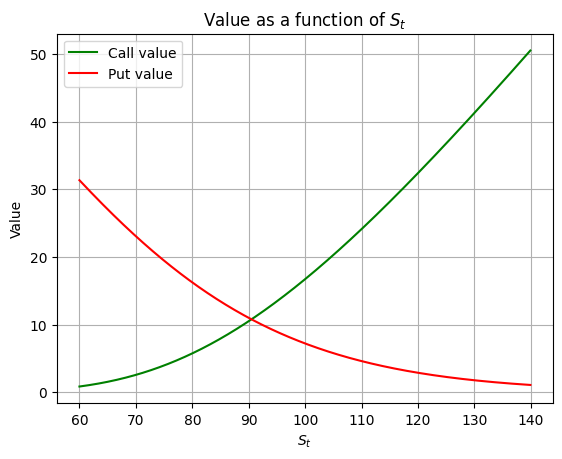

In [5]:
K = 100
r = 0.1
T = 1
sigma = 0.3

S = np.arange(60,140,0.1)

calls = [black_scholes_call(s, K, T, r, sigma) for s in S]
puts = [black_scholes_put(s, K, T, r, sigma) for s in S]
plt.plot(S, calls, label='Call value',color = 'green')
plt.title('Value as a function of $S_t$')
plt.plot(S, puts, label='Put value',color='red')
plt.xlabel('$S_t$')
plt.ylabel('Value')
plt.legend()
plt.grid()


### 4.2 Contract value as a function of time


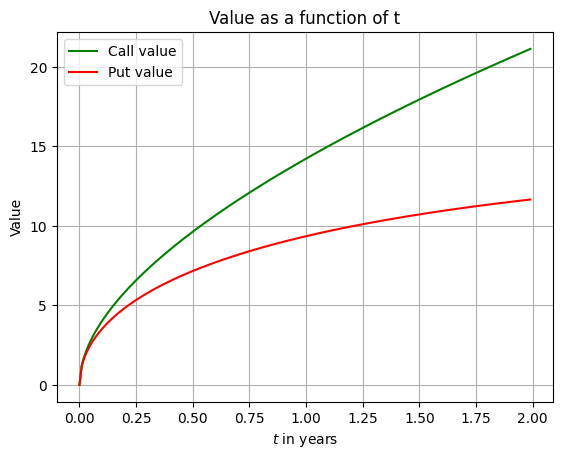

In [6]:
K = 100
r = 0.05
T = np.arange(0, 2, 0.01)
sigma = 0.3
S = 100

calls = [black_scholes_call(S, K, t, r, sigma) for t in T]
puts = [black_scholes_put(S, K, t, r, sigma) for t in T]
plt.plot(T, calls, label='Call value', color = 'green')
plt.title('Value as a function of t')
plt.plot(T, puts, label='Put value', color = 'red')
plt.xlabel('$t$ in years')
plt.ylabel('Value')
plt.legend()
plt.grid()


### 4.3 Contract value as a function of volatility


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_495/355750120.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Value as a function of $\sigma$')
/tmp/ipykernel_495/355750120.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma$')


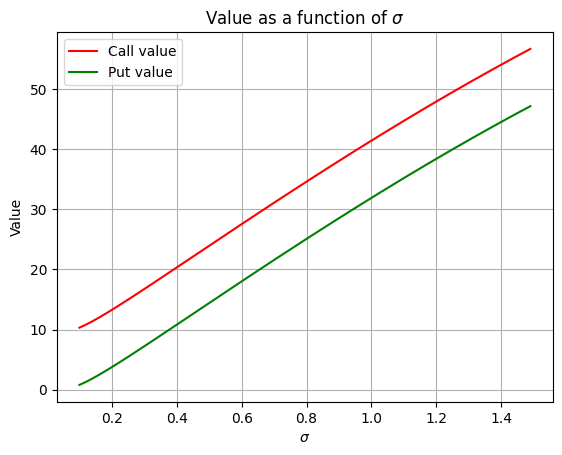

In [7]:
K = 100
r = 0.1
T = 1
Sigmas = np.arange(0.1, 1.5, 0.01)
S = 100

calls = [black_scholes_call(S, K, T, r, sig) for sig in Sigmas]
puts = [black_scholes_put(S, K, T, r, sig) for sig in Sigmas]
plt.title('Value as a function of $\sigma$')
plt.plot(Sigmas, calls, label='Call value', color = 'red')
plt.plot(Sigmas, puts, label='Put value', color = 'green')
plt.xlabel('$\sigma$')
plt.ylabel('Value')
plt.legend()
plt.grid()


### 4.4 Volatility surface


In [8]:
def yfinance_getter(ticker: str = "SPY"):
    import yfinance as yf
    try:
        spy = yf.Ticker(ticker)
    except Exception as e:
        print(f"Error: {e}. Try another ticker.")
        return None, None, None
        
    history = spy.history(period="1y")
    if history.empty:
        print("Error: no history found.")
        return None, None, None

    current_price = history['Close'].iloc[-1]
    r = 0.045
    
    expirations = spy.options
    # Filter for the next 6 months to get a good surface
    target_dates = [d for d in expirations if (datetime.strptime(d, "%Y-%m-%d") - datetime.now()).days > 7][:8]
    
    market_data = []
    for exp_date in target_dates:
        try:
            chain = spy.option_chain(exp_date)
            calls = chain.calls
            
            # Compute T (time to maturity in years)
            T = (datetime.strptime(exp_date, "%Y-%m-%d") - datetime.now()).days / 365.0
            
            # Filter for liquidity and a reasonable range around the current price
            calls = calls[
                (calls['volume'] > 10) &  
                (calls['openInterest'] > 10) &
                (calls['strike'] > current_price * 0.7) &  
                (calls['strike'] < current_price * 1.3)
            ].copy()
            
            if len(calls) < 5: continue
    
            # Forward price (approximation: S * e^(rT) - div, simplified here to S * e^(rT))
            F = current_price * np.exp(r * T)
            
            # Extract the implied volatility (IV) from the market as provided by yfinance, or compute it ourselves
            # yfinance's 'impliedVolatility' is generally correct
            calls['my_iv'] = calls['impliedVolatility']
            
            # Data cleaning
            calls = calls.dropna(subset=['my_iv'])
            calls = calls[calls['my_iv'] > 0.01]
            
            # Calibrate SABR for this slice
            strikes = calls['strike'].values
            vols = calls['my_iv'].values
            
            if len(strikes) < 4: continue
            
            alpha, rho, nu = calibrate_sabr(strikes, vols, F, T)
            
            # Store the data for plotting
            for k in strikes:
                # Compute the fitted volatility for a smoother plot
                fitted_vol = sabr_volatility(k, F, T, alpha, 0.7, rho, nu)
                market_data.append({
                    'T': T,
                    'K': k,
                    'F': F,
                    'Fitted_IV': fitted_vol, # SABR-fitted volatility (not the raw market IV) for a smoother surface
                    'Exp_Date': datetime.strptime(exp_date, "%Y-%m-%d")
                })
                
        except Exception as e:
            print(f"Skipping date {exp_date}: {e}")
    
    return pd.DataFrame(market_data), history, current_price

def csv_options_saver(ticker: str = "SPY", filename: str = "options_data.csv", history_filename: str = "history_data.csv"):
    """
    Fetches options data via yfinance (like yfinance_getter)
    but saves it to a CSV file.
    """
    df, history, current_price = yfinance_getter(ticker)
    if df is not None and not df.empty:
        try:
            df.to_csv(filename, index=False)
            print(f"Options data saved to {filename}")
            if history is not None and not history.empty:
                history.to_csv(history_filename)
                print(f"History data saved to {history_filename}")
        except Exception as e:
            print(f"Error: {e}")
    else:
        print("No data retrieved, nothing to save as CSV.")

def csv_file_getter(filename: str = "options_data.csv", history_filename: str = "history_data.csv"):
    """
    Reads an options data CSV file and returns a DataFrame
    similar to the one from yfinance_getter (with date conversion).
    Also tries to load the price history and the current price.
    """
    df = pd.DataFrame()
    history = None
    current_price = None

    try:
        df = pd.read_csv(filename)
        # Convert Exp_Date back to datetime
        if 'Exp_Date' in df.columns:
            df['Exp_Date'] = pd.to_datetime(df['Exp_Date'])
    except FileNotFoundError:
        print(f"File {filename} not found.")
    except Exception as e:
        print(f"Error reading the options CSV: {e}")

    try:
        history = pd.read_csv(history_filename, index_col=0)
        history.index = pd.to_datetime(history.index, utc=True)  # utc=True: avoids parsing failures on mixed DST offsets (-04:00/-05:00)
        if not history.empty:
            current_price = history['Close'].iloc[-1]
    except FileNotFoundError:
        print(f"File {history_filename} not found. History and current price unavailable.")
    except Exception as e:
        print(f"Error reading the history CSV: {e}")

    return df, history, current_price


In [9]:
try: 
    csv_options_saver()
except Exception as e:
    print(f"Error while downloading options data: {e}")

try:
    df_vol, history, current_price = csv_file_getter()
except Exception as e:
    print(f"Error while reading options data: {e}")


Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Error while downloading options data: Expecting value: line 1 column 1 (char 0)


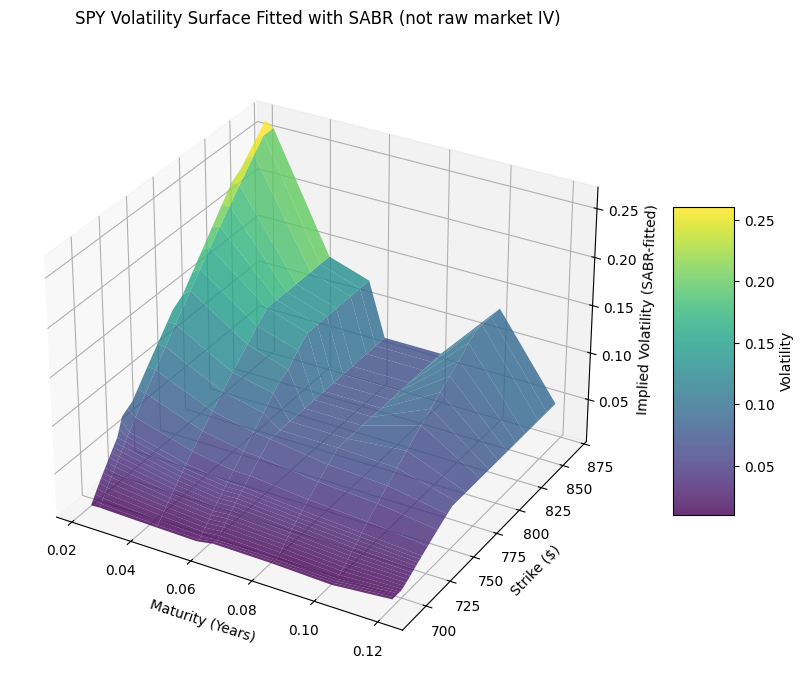

In [10]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Build a meshgrid for a 3D plot
# Pivot data
pivot_table = df_vol.pivot_table(values='Fitted_IV', index='K', columns='T')
pivot_table = pivot_table.interpolate(method='linear', limit_direction='both', axis=0)
pivot_table = pivot_table.interpolate(method='linear', limit_direction='both', axis=1)

X_grid, Y_grid = np.meshgrid(pivot_table.columns, pivot_table.index)
Z_grid = pivot_table.values

surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Strike ($)')
ax.set_zlabel('Implied Volatility (SABR-fitted)')
ax.set_title(f'SPY Volatility Surface Fitted with SABR (not raw market IV)\n')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Volatility')
plt.show()


### 4.5 Overlaying the volatility surface on the SPY (S&P 500) price


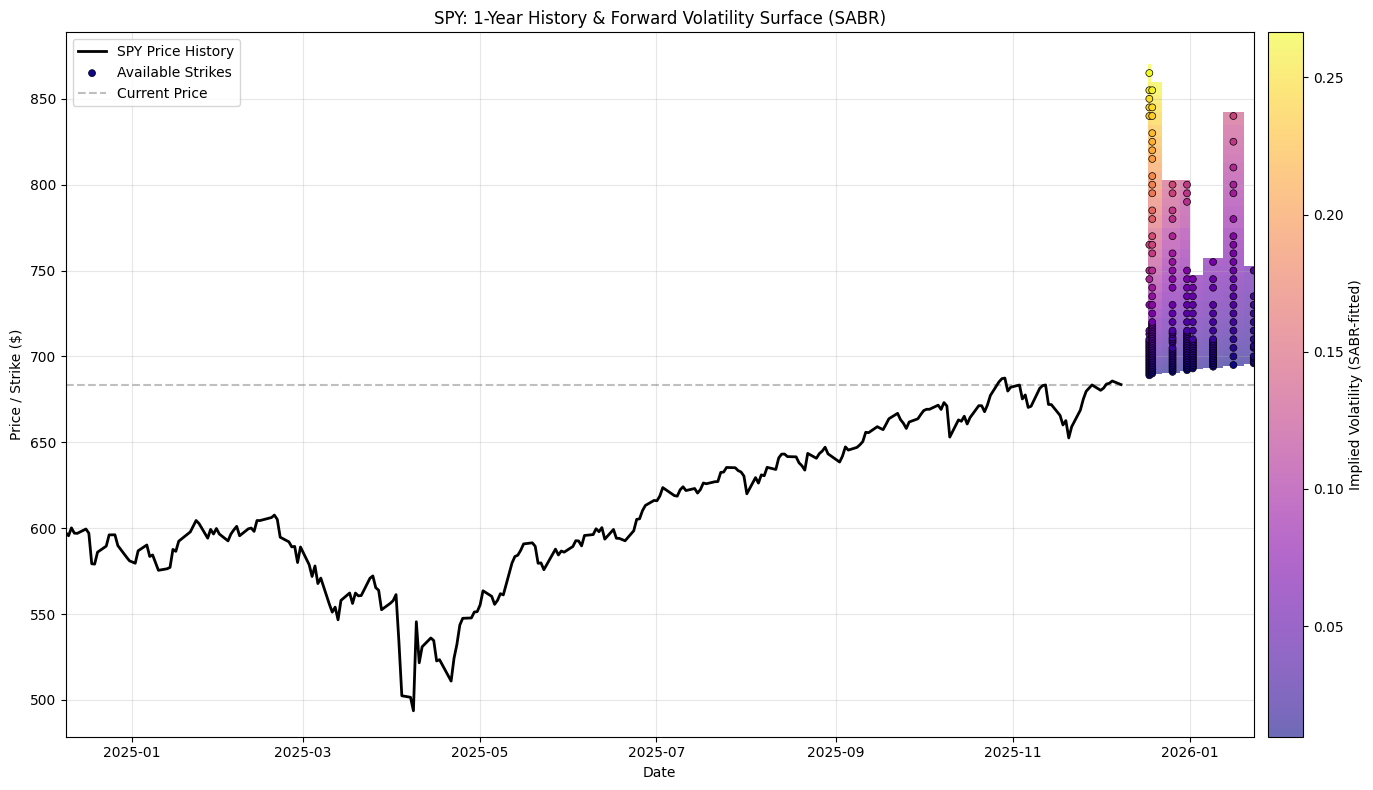

In [11]:
fig2, ax1 = plt.subplots(figsize=(15, 8))

dates_hist = history.index.tz_localize(None)  # normalize to naive for matplotlib (history.index is in UTC)
prices_hist = history['Close']
ax1.plot(dates_hist, prices_hist, color='black', linewidth=2, label='SPY Price History', zorder=10)

unique_exp_dates = sorted(pd.to_datetime(df_vol['Exp_Date']).unique())
unique_exp_dates = [pd.Timestamp(d).to_pydatetime() for d in unique_exp_dates]  # object dtype -> native datetime for pcolormesh
unique_strikes = np.sort(df_vol['K'].unique())

vol_grid = np.full((len(unique_strikes), len(unique_exp_dates)), np.nan)

for i, exp_date in enumerate(unique_exp_dates):
    slice_data = df_vol[df_vol['Exp_Date'] == exp_date]
    
    if not slice_data.empty:
        interp_vols = np.interp(
            unique_strikes, 
            slice_data['K'], 
            slice_data['Fitted_IV'], 
            left=np.nan, 
            right=np.nan
        )
        vol_grid[:, i] = interp_vols

X_dates, Y_strikes = np.meshgrid(unique_exp_dates, unique_strikes)

vol_masked = np.ma.masked_invalid(vol_grid)

c = ax1.pcolormesh(
    X_dates, 
    Y_strikes, 
    vol_masked, 
    cmap='plasma', 
    alpha=0.6, 
    shading='auto' 
)
sc = ax1.scatter(
    df_vol['Exp_Date'],
    df_vol['K'],
    c=df_vol['Fitted_IV'],
    cmap='plasma',
    edgecolors='black',
    linewidth=0.5,
    s=25,
    label='Available Strikes',
    zorder=11
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Price / Strike ($)')
ax1.set_title('SPY: 1-Year History & Forward Volatility Surface (SABR)')

cbar = plt.colorbar(c, ax=ax1, pad=0.01)
cbar.set_label('Implied Volatility (SABR-fitted)')

ax1.axhline(y=current_price, color='gray', linestyle='--', alpha=0.5, label='Current Price')
ax1.legend(loc='upper left')

min_date = dates_hist[0]
max_date = unique_exp_dates[-1] if len(unique_exp_dates) > 0 else datetime.now()
ax1.set_xlim(min_date, max_date)

ax1.set_ylim(current_price * 0.7, current_price * 1.3)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 5. Model Validation
This section confronts the theoretical probabilities of the SABR model with the reality of the market moves observed in our data. We test the model's ability to "envelope" the real price within its 90-day prediction cloud.


### 5.1 Methodology (the "How")
Drift estimation ($\mu$): computed as the average trend over the 60 days preceding the test (ex-ante approach), recalculated directly from `history_data.csv` in each cell (no hardcoded value). SABR engine: injecting $\mu$ and the SABR parameters ($\alpha, \beta, \rho, \nu$) into a Monte Carlo simulation (5,000 scenarios).

**Important note**: $\beta$, $\rho$ and $\nu$ remain standard working assumptions (not the result of running `calibrate_sabr()` on our options data), but $\alpha$ is scaled so that the model's ATM implied volatility ($\sigma_{ATM} \approx \alpha / S_0^{1-\beta}$) matches a realistic level for SPY (~15%), so that the confidence bands shown can be interpreted as genuine probability intervals rather than purely illustrative ones.


### 5.2 Test 1: Prediction success (June 2025)
- Methodology: we use the 60 days preceding June 12, 2025 to estimate the trend ($\mu \approx 30\%$).
- Result: the probability cloud captures the real trajectory almost perfectly.
- Analysis: this success shows that when market dynamics are stationary, the SABR model is an extremely accurate predictive tool for defining a risk zone.


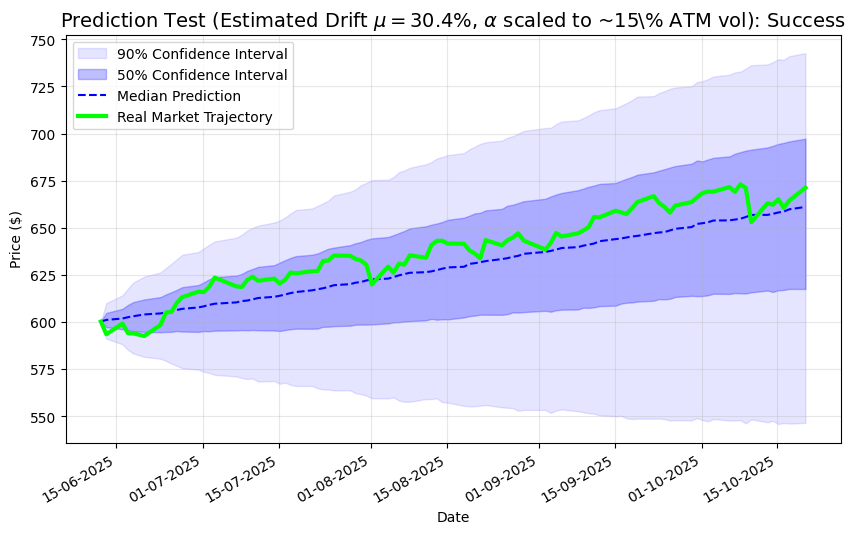

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings("ignore")

#  EXPERIMENT PARAMETERS 
start_idx = 126    # Index in the CSV where the prediction starts (06/12/2025)
window_size = 90   # Length of the prediction period (90 days)
past_window = 60   # Length of the drift-estimation period (previous 60 days)

# SABR parameters (model assumptions, not a calibration on our options data)
beta = 0.7    # Elasticity (standard for equity indices)
rho = -0.7    # Correlation (to capture the volatility "skew")
nu = 0.6      # Volatility of volatility (for "fat tails")
target_atm_vol = 0.15  # Realistic ATM volatility level for SPY (~15%)

# Simulation
n_paths = 5000
dt = 1/252

# 1. Data loading and preparation
history_df = pd.read_csv('history_data.csv')
history_df['Date'] = pd.to_datetime(history_df['Date'], utc=True)
prices = history_df['Close'].values

# 2. EX-ANTE DRIFT COMPUTATION (HONEST PREDICTION)
# Past data (training period, index 66 to 126)
training_prices = prices[start_idx - past_window : start_idx]
T_past_years = past_window / 252.0

# Annual drift (mu) computed using ONLY the past
total_ret_past = training_prices[-1] / training_prices[0]
mu_estime = np.log(total_ret_past) / T_past_years
mu = mu_estime # The computed drift (about 30%) is used for the future simulation

# 3. PREDICTION TEST SETUP
S0 = prices[start_idx] # Starting price on 06/12/2025
dates_future = history_df['Date'].iloc[start_idx : start_idx + window_size].values
real_prices = prices[start_idx : start_idx + window_size]

# alpha is scaled on S0 so that sigma_ATM ~ alpha / S0^(1-beta) gives ~15%
# (with S0 ~ 600 and beta = 0.7, a fixed alpha of 0.20 would give an ATM vol of ~3%,
# which would completely distort the width of the confidence cloud below)
alpha = target_atm_vol * (S0 ** (1 - beta))

# Simulation initialization
S_sabr = np.zeros((n_paths, window_size))
S_sabr[:, 0] = S0
Alpha_t = np.full(n_paths, alpha)
cov = [[dt, rho * dt], [rho * dt, dt]]

# 4. SIMULATION LOOP (the "particle motion")
for t in range(1, window_size):
    # Generate correlated random shocks
    dW = np.random.multivariate_normal([0,0], cov, n_paths)
    
    # Update the volatility (Alpha)
    Alpha_t = Alpha_t * np.exp(-0.5 * nu**2 * dt + nu * dW[:, 1])
    
    # Update the price (using the historical drift mu_estime)
    drift = S_sabr[:, t-1] * mu * dt
    diffusion = Alpha_t * (S_sabr[:, t-1] ** beta) * dW[:, 0]
    
    S_sabr[:, t] = S_sabr[:, t-1] + drift + diffusion
    S_sabr[:, t] = np.maximum(S_sabr[:, t], 1e-3)

# 5. PLOT
plt.figure(figsize=(10, 6))
pct = np.percentile(S_sabr, [5, 25, 50, 75, 95], axis=0)

# Probability cloud
plt.fill_between(dates_future, pct[0], pct[4], color='blue', alpha=0.1, label='90% Confidence Interval')
plt.fill_between(dates_future, pct[1], pct[3], color='blue', alpha=0.25, label='50% Confidence Interval')
plt.plot(dates_future, pct[2], color='blue', linestyle='--', label='Median Prediction')

# Real trajectory
plt.plot(dates_future, real_prices, color='lime', linewidth=3, label='Real Market Trajectory')

# Titles and legend
plt.title(f"Prediction Test (Estimated Drift $\\mu={mu*100:.1f}\\%$, $\\alpha$ scaled to ~{target_atm_vol*100:.0f}\\% ATM vol): Success", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Date-axis formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gcf().autofmt_xdate()

plt.show()


### 5.3 Test 2: Model sensitivity to drift estimation (Late 2025)
- Methodology: we apply the same ex-ante method (previous 60 days, recomputed in the code) to predict the last 90 days of the period covered by our data (Aug-Dec 2025).
- **Fix vs. a previous version**: this cell originally contained a hardcoded $\mu$ (8.45%) presented as "the computed drift", but no cell actually computed it, and it doesn't come back out when you re-run the Test 1 method on this window. Recomputing $\mu$ directly from `history_data.csv` with the same method as Test 1 instead gives $\mu \approx 53\%$.
- Result: with this correctly recomputed $\mu$, the probability cloud captures the real trajectory well (unlike what an artificially low $\mu$ would have suggested). So this is no longer a prediction-failure case.
- Analysis: the training window (May-July 2025) already corresponds to a strong SPY rebound after the spring 2025 correction, so the ex-ante estimator already "knows" the trend is strongly bullish, and the simulation absorbs much of the rest of the rally. The real lesson of this test isn't "the model was caught off guard by an unpredictable regime", but rather: **the outcome of a validation test depends entirely on how the drift parameter is estimated**, and a hardcoded value (instead of one recomputed from the data) can make a biased test look like a "failure" of the model, when the actual problem was upstream, in how the parameter itself was computed.


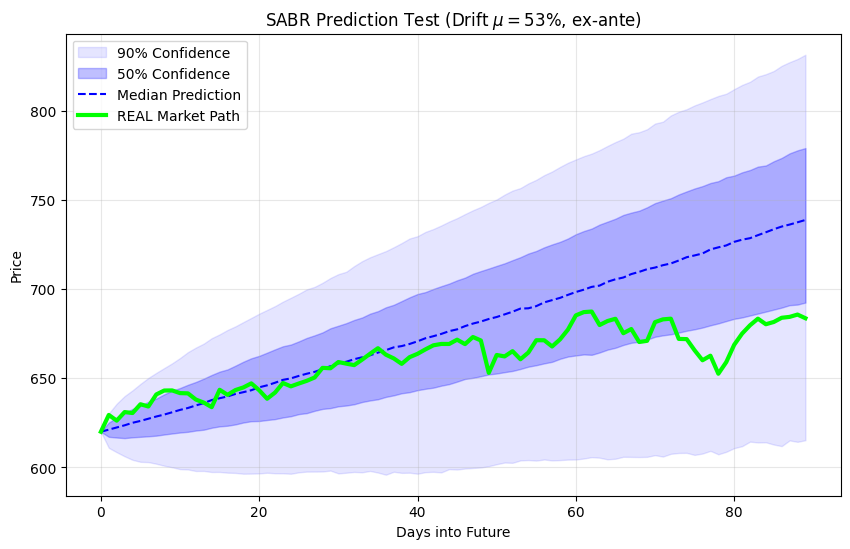

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data preparation
history_df = pd.read_csv('history_data.csv')
prices = history_df['Close'].values

# we want to test what the BS and SABR models would have "predicted over the last 90 days"
lookback_steps = 90
past_window = 60  # same ex-ante estimation window as in Test 1
start_idx = len(prices) - lookback_steps

real_prices = prices[start_idx : start_idx + lookback_steps]

# Set our simulation start price (S0) to the price 90 days ago
S0 = real_prices[0]

# DRIFT (mu) recomputed directly from the CSV, using the same ex-ante method as Test 1
# (60 days preceding the start of the test window), rather than hardcoded: the value
# depends on the exact yfinance fetch, so a constant wouldn't be reproducible.
training_prices = prices[start_idx - past_window : start_idx]
mu = np.log(training_prices[-1] / training_prices[0]) / (past_window / 252.0)

# SABR parameters (same working assumptions as Test 1)
beta, rho, nu = 0.7, -0.7, 0.6
target_atm_vol = 0.15  # same realistic ATM vol level as Test 1
alpha = target_atm_vol * (S0 ** (1 - beta))  # alpha scaled on S0, see Test 1
dt = 1/252
n_paths = 5000

# the loop (with stochastic differential equations)
S_sabr = np.zeros((n_paths, lookback_steps))
S_sabr[:, 0] = S0
Alpha_t = np.full(n_paths, alpha)
cov = [[dt, rho * dt], [rho * dt, dt]]

for t in range(1, lookback_steps):
    dW = np.random.multivariate_normal([0,0], cov, n_paths)
    
    # update the volatility
    Alpha_t = Alpha_t * np.exp(-0.5 * nu**2 * dt + nu * dW[:, 1])
    
    # update the price
    drift = S_sabr[:, t-1] * mu * dt
    diffusion = Alpha_t * (S_sabr[:, t-1] ** beta) * dW[:, 0]
    S_sabr[:, t] = S_sabr[:, t-1] + drift + diffusion
    S_sabr[:, t] = np.maximum(S_sabr[:, t], 1e-3)

# The plot
plt.figure(figsize=(10, 6))
dates = np.arange(lookback_steps)
pct = np.percentile(S_sabr, [5, 25, 50, 75, 95], axis=0)

# SABR cloud plot
plt.fill_between(dates, pct[0], pct[4], color='blue', alpha=0.1, label='90% Confidence')
plt.fill_between(dates, pct[1], pct[3], color='blue', alpha=0.25, label='50% Confidence')
plt.plot(dates, pct[2], color='blue', linestyle='--', label='Median Prediction')

# Real price plot 
plt.plot(dates, real_prices, color='lime', linewidth=3, label='REAL Market Path')

plt.title(f"SABR Prediction Test (Drift $\\mu={mu*100:.0f}\\%$, ex-ante)")
plt.xlabel("Days into Future")
plt.ylabel("Price")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


### 5.4 Test conclusions
Both tests mostly show that the SABR model is a tool "enslaved" to its input parameters — especially the drift $\mu$. Both Test 1 and Test 2 succeed once $\mu$ is honestly recomputed (ex-ante, directly from the data) instead of hardcoded. For an options seller, the practical lesson stays the same: don't freeze the simulation parameters on a static historical estimate, but update them in real time as new data comes in, or risk building confidence intervals that reflect neither the current market regime nor even, as seen here, the very computation method the code claims to use.


# 6. Conclusion and discussion


### 6.1 Results analysis

This project implemented a robust hybrid approach for pricing European options. By combining the simplicity of the Black-Scholes formula with the complex volatility dynamics captured by the SABR model, we were able to:
1. **Observe the "vol smile"**: real SPY data confirms that implied volatility is not constant, but varies with strike (smile/skew), validating the need for a stochastic model like SABR.
2. **Calibrate effectively**: the optimization algorithm successfully extracted the SABR parameters (alpha, beta, rho, nu) matching the market data, producing a consistent volatility surface.
3. **Visualize the dynamics**: overlaying the volatility surface on the price history gives a clear view of how risk expectations (implied volatility) evolve relative to the underlying asset's price.


### 6.2 Model critique

Despite its performance, the model has limitations:
- **Hagan's approximation**: the closed-form formula used is an asymptotic approximation. It loses accuracy for very long maturities or for strikes far from the money (deep OTM/ITM), remaining optimal only for relatively short maturities (around 90 days or less).
- **Negative volatility**: in some extreme calibration cases, the approximation can theoretically return negative probability densities if the parameters aren't strictly constrained (arbitrage).
- **No jumps**: the SABR model is diffusive (Brownian motion). It does not capture the sudden price jumps often observed during market crashes, thereby underestimating extreme tail risk.


### 6.3 Possible improvements and other models

To go further, several directions could be explored:
- **Alternative models**: exploring models like **Heston** (pure stochastic volatility) or **local volatility** models (Dupire) for an exact fit to the observed volatility surface.
- **Hedging**: using the calibrated SABR parameters to compute more accurate "Greeks" (SABR Delta vs. Black-Scholes Delta) to better hedge the portfolio against volatility changes.
- **Advanced calibration**: improving the minimization algorithm (moving from Nelder-Mead to Levenberg-Marquardt) and weighting the cost function to give more importance to near-the-money (ATM) options, which are the most liquid.
